# Democratic Resilience Panel: V-Dem + SWIID + OWID + ERT + SOCX (1960–2023)

**Dataset**: `democratic_resilience_panel`

Country-year panel (11,733 observations, 190 countries, 1960–2023) merging:
- **V-Dem** electoral democracy index (EDI) and liberal democracy index (LDI) via OWID
- **ERT** gradual-erosion and coup-onset flags
- **SWIID v7.1** market/net Gini with standard errors
- **OWID** Luxembourg Income Study redistribution series
- **OECD SOCX** gross social spending
- **Penn World Table** rgdpe_pc GDP per capita
- **Lee-Lee/Barro-Lee** schooling
- Derived **democratic-stock** variable (cumulative prior years with EDI ≥ 0.5)

This notebook loads a curated 100-example mini dataset and demonstrates the schema and key statistics.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab
_pip('loguru==0.7.3')

# Core packages — pre-installed on Colab, install locally to match Colab versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

Standard library imports plus the schema constants from the original `data.py` script.

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from loguru import logger

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

# Columns used as input features (predictors of democratic resilience)
INPUT_COLS = [
    "year", "edi", "ldi",
    "gini_market", "gini_net",
    "redistribution_swiid", "redistribution_swiid_se",
    "redistribution_owid",
    "gross_socx", "gdp_pc", "schooling",
    "ert_onset_gradual", "ert_onset_coup", "ert_episode_id",
    "democratic_stock",
]

## Data Loading

Loads `mini_demo_data.json` from GitHub (100 diverse country-year examples). Falls back to a local file when GitHub is unreachable.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-a5d3bf-the-welfare-state-as-a-recovery-rate-gov/main/round-1/dataset-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
logger.info(f"Loaded dataset with {len(data['datasets'][0]['examples'])} examples")

03:18:44|INFO   |Loaded dataset with 100 examples


## Config

Tunable parameters for the demo. Set to minimum values — increase for a fuller run.

In [5]:
# Number of examples to process (None = all)
N_EXAMPLES = None  # original: None (all 11,733)

## Processing

Mirrors `data.py`: iterates over panel rows, extracts input feature columns as a JSON string, and packages each row as an `(input, output, metadata)` example record.

In [6]:
rows_raw = data["datasets"][0]["examples"]
if N_EXAMPLES is not None:
    rows_raw = rows_raw[:N_EXAMPLES]

logger.info(f"Processing {len(rows_raw)} rows")

examples = []
for row_ex in rows_raw:
    # Parse the input JSON string back into a dict
    row = json.loads(row_ex["input"])
    row["country_code"] = row_ex["output"]
    row.update({k: row_ex[k] for k in row_ex if k.startswith("metadata_")})

    # input: all feature columns as JSON string
    inp_fields = {k: row.get(k) for k in INPUT_COLS if k in row}
    input_str = json.dumps(inp_fields, ensure_ascii=False)

    # output: country_code (the unit of analysis for democratic resilience studies)
    output_str = str(row["country_code"])

    ex = {
        "input": input_str,
        "output": output_str,
        "metadata_country_code": row["country_code"],
        "metadata_year": row_ex["metadata_year"],
        "metadata_task_type": "panel_data",
        "metadata_democratic_stock": row_ex.get("metadata_democratic_stock"),
        "metadata_edi": row_ex.get("metadata_edi"),
    }
    examples.append(ex)

logger.info(f"Built {len(examples)} examples")

03:18:44|INFO   |Processing 100 rows


03:18:44|INFO   |Built 100 examples


## Output Structure

The processed output mirrors `full_data_out.json`: a metadata block + a list of `(input, output, metadata_*)` examples.

In [7]:
out = {
    "metadata": data["metadata"],
    "datasets": [
        {
            "dataset": "democratic_resilience_panel",
            "examples": examples,
        }
    ],
}

print(f"Output: {len(examples)} examples")
print("Sample example keys:", list(examples[0].keys()))
print("\nSample input (parsed):")
print(json.dumps(json.loads(examples[0]['input']), indent=2))

Output: 100 examples
Sample example keys: ['input', 'output', 'metadata_country_code', 'metadata_year', 'metadata_task_type', 'metadata_democratic_stock', 'metadata_edi']

Sample input (parsed):
{
  "year": 1960,
  "edi": 0.082,
  "ldi": 0.066,
  "gini_market": null,
  "gini_net": null,
  "redistribution_swiid": null,
  "redistribution_swiid_se": null,
  "redistribution_owid": null,
  "gross_socx": null,
  "gdp_pc": null,
  "schooling": 0.22,
  "ert_onset_gradual": null,
  "ert_onset_coup": null,
  "ert_episode_id": null,
  "democratic_stock": 0.0
}


## Visualization

Key statistics from the panel: EDI distribution, democratic stock, and coverage summary.

=== Dataset Summary ===
Examples: 100
Countries: 100
Year range: 1960–2022
EDI mean: 0.418
Democratic stock mean: 7.9
GDP per capita coverage: 82/100
Gini net coverage: 41/100
Social spending coverage: 18/100


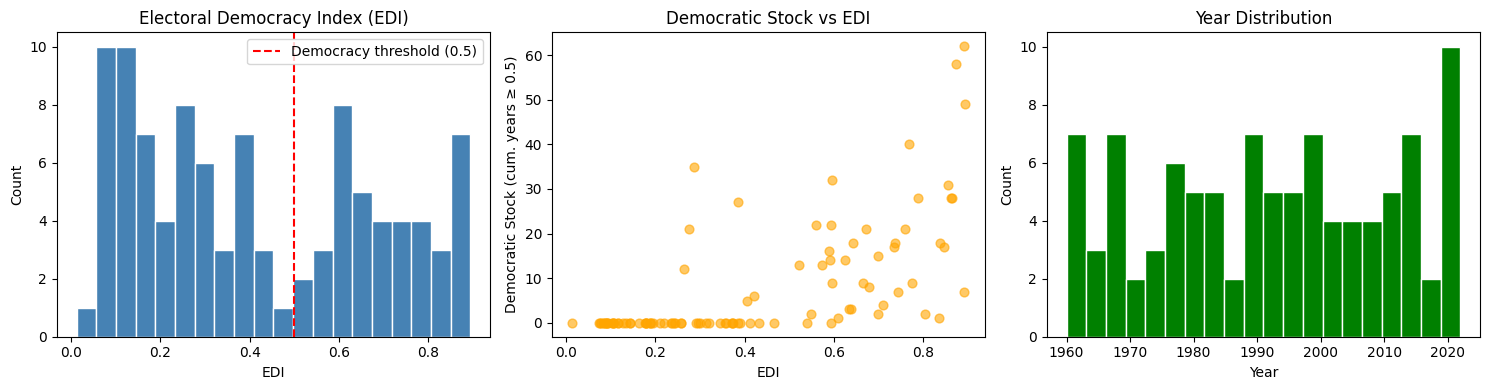

Saved: demo_panel_stats.png


In [8]:
# Build a DataFrame for easy analysis
records = []
for ex in examples:
    inp = json.loads(ex["input"])
    records.append({
        "country_code": ex["metadata_country_code"],
        "year": ex["metadata_year"],
        "edi": ex["metadata_edi"],
        "democratic_stock": ex["metadata_democratic_stock"],
        "gdp_pc": inp.get("gdp_pc"),
        "gini_net": inp.get("gini_net"),
        "gross_socx": inp.get("gross_socx"),
    })
df = pd.DataFrame(records)

print("=== Dataset Summary ===")
print(f"Examples: {len(df)}")
print(f"Countries: {df['country_code'].nunique()}")
print(f"Year range: {df['year'].min()}–{df['year'].max()}")
print(f"EDI mean: {df['edi'].mean():.3f}")
print(f"Democratic stock mean: {df['democratic_stock'].mean():.1f}")
print(f"GDP per capita coverage: {df['gdp_pc'].notna().sum()}/{len(df)}")
print(f"Gini net coverage: {df['gini_net'].notna().sum()}/{len(df)}")
print(f"Social spending coverage: {df['gross_socx'].notna().sum()}/{len(df)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# EDI distribution
axes[0].hist(df['edi'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(0.5, color='red', linestyle='--', label='Democracy threshold (0.5)')
axes[0].set_title('Electoral Democracy Index (EDI)')
axes[0].set_xlabel('EDI')
axes[0].set_ylabel('Count')
axes[0].legend()

# Democratic stock vs EDI
axes[1].scatter(df['edi'], df['democratic_stock'], alpha=0.6, color='orange', s=40)
axes[1].set_title('Democratic Stock vs EDI')
axes[1].set_xlabel('EDI')
axes[1].set_ylabel('Democratic Stock (cum. years ≥ 0.5)')

# Year distribution
axes[2].hist(df['year'], bins=20, color='green', edgecolor='white')
axes[2].set_title('Year Distribution')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('demo_panel_stats.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: demo_panel_stats.png')